# Parameter Inference for 21-cm Cosmology: From ABC to Neural Posterior Estimation

In this module, we tackle the inverse problem of cosmological parameter estimation. Our objective is to infer the mean ionization fraction of the intergalactic medium ($Q_{\mathrm{HII}}$) from a simulated 21-cm power spectrum ($\Delta^2_{21}(k)$). 

Because the physics of the Epoch of Reionization involves complex, non-linear radiative transfer, evaluating a tractable, exact likelihood function $P(d \mid \theta)$ is computationally prohibitive. Instead, we must rely on forward-modelled mock observations.

This notebook introduces and compares three distinct approaches to parameter estimation:
* **Approximate Bayesian Computation (ABC):** A foundational likelihood-free method that accepts prior samples based on a strict Euclidean distance threshold from the target observation.
* **Markov Chain Monte Carlo (MCMC):** A traditional likelihood-based sampling technique, loaded here to serve as a baseline for posterior shape and median convergence. 
* **Simulation-Based Inference (SBI):** A modern machine learning approach utilizing a Neural Posterior Estimator (NPE). We will train a Neural Spline Flow to approximate the true posterior $P(\theta \mid d)$ directly from a bank of pre-computed simulations.

By the end of this notebook, you will see how normalizing flows can bypass the curse of dimensionality inherent in ABC and vastly accelerate parameter estimation for complex astrophysics pipelines.

**Visualizing the Joint Distribution**

Before performing any inference, we must examine the joint distribution $P(d, \theta)$ generated by our forward-modelling pipeline. In this context, our parameter $\theta$ represents the mean ionization fraction $Q_{\mathrm{HII}}$, and our data $d$ represents the 21-cm power spectrum amplitude $\Delta^2_{21}(k)$ at a specific spatial scale. The scatter plot below illustrates how variations in the reionization history map to observable power, bounded by our uniform prior.

Loaded 10000 samples from sbi_abc_samples.npz.
Using 10000 samples.


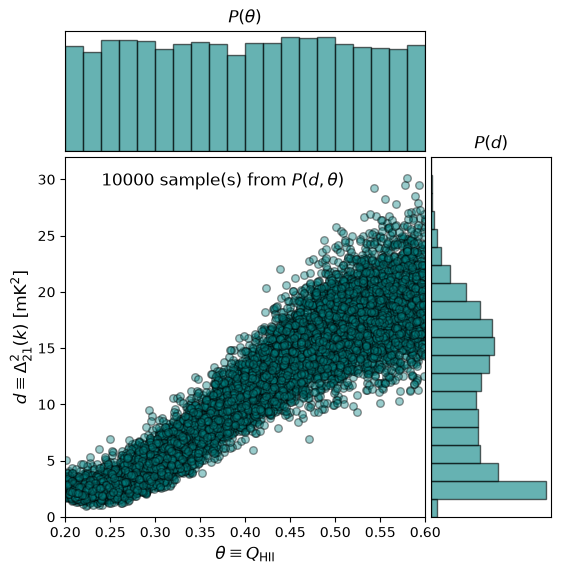

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sim_utils

# Load the shared configuration
cfg = sim_utils.load_config("config.yaml")
num_use_samples = 10000
bins_marginal = 20

# Load the ABC prior samples dynamically
file_path = cfg["output_file"]
data = np.load(file_path)

seeds = data['seeds']
zeta_prior = data['zeta']
qhii_prior = data['QHII_mean']
P_prior = data['P_all']
k_bins = data['k_bins']
k_val = k_bins[0]
P_k_prior = P_prior[:, 0]

P_k_min = 0.0
P_k_max = 32.0

print(f"Loaded {len(seeds)} samples from {file_path}.")

num_use_samples = min(num_use_samples, len(seeds))
seeds = seeds[:num_use_samples]
zeta_prior = zeta_prior[:num_use_samples]
qhii_prior = qhii_prior[:num_use_samples]
P_k_prior = P_k_prior[:num_use_samples]

print (f"Using {num_use_samples} samples.")


qhii_edges = np.linspace(float(cfg["QHII_min"]), float(cfg["QHII_max"]), bins_marginal + 1)
qhii_bins = 0.5 * (qhii_edges[:-1] + qhii_edges[1:])
P_k_edges = np.linspace(P_k_min, P_k_max, bins_marginal + 1)
P_k_bins = 0.5 * (P_k_edges[:-1] + P_k_edges[1:])

qhii_hist, _ = np.histogram(qhii_prior, bins=qhii_edges, density=True)
P_k_hist, _ = np.histogram(P_k_prior, bins=P_k_edges, density=True)

# Plot the Joint Distribution with marginal 1D histograms
fig = plt.figure(figsize=(6, 6))

# Define axes positions
left = 0.12
bottom = 0.12
width = 0.60
height = 0.60
spacing = 0.01
hist_width = 0.20

ax_joint = fig.add_axes([left, bottom, width, height])
ax_marg_x = fig.add_axes([left, bottom + height + spacing, width, hist_width])
ax_marg_y = fig.add_axes([left + width + spacing, bottom, hist_width, height])

# Joint scatter plot
ax_joint.scatter(qhii_prior, P_k_prior, alpha=0.4, color='teal', edgecolor='k', s=30)
ax_joint.set_xlabel(r"$\theta \equiv Q_{{\mathrm{{HII}}}}$", fontsize=12)
ax_joint.set_ylabel(r"$d \equiv \Delta^2_{{21}}(k)\ [\mathrm{{mK}}^2]$", fontsize=12)
ax_joint.set_xlim(float(cfg["QHII_min"]), float(cfg["QHII_max"]))
ax_joint.set_ylim(P_k_min, P_k_max)
ax_joint.text(0.1, 0.92, f"${num_use_samples}$ sample(s) from $P(d, \\theta)$", fontsize=12, transform=ax_joint.transAxes)

# Top marginal: histogram of QHII
ax_marg_x.hist(qhii_edges[:-1], bins=qhii_edges, weights=qhii_hist, color='teal', edgecolor='k', alpha=0.6)
ax_marg_x.set_xlim(ax_joint.get_xlim())
ax_marg_x.set_yticks([])
ax_marg_x.set_xticks([])
ax_marg_x.set_title("$P(\\theta)$", fontsize=12)

# Right marginal: histogram of P21
ax_marg_y.hist(P_k_edges[:-1], bins=P_k_edges, weights=P_k_hist, color='teal', edgecolor='k', alpha=0.6, orientation='horizontal')
ax_marg_y.set_ylim(ax_joint.get_ylim())
ax_marg_y.set_xticks([])
ax_marg_y.set_yticks([])
ax_marg_y.set_ylabel("")
ax_marg_y.set_title("$P(d)$", fontsize=12)#, rotation=0, x=0.5, y=1.0)

plt.show()

In [2]:
import os

mcmc_file = cfg.get("mcmc_output_file", "mcmc_samples.npz")

if (os.path.exists(mcmc_file)):
    print(f"Loading MCMC samples from {mcmc_file}...")
    mcmc_data = np.load(mcmc_file)

    target_QHII = mcmc_data['target_QHII']
    target_P_k = mcmc_data['target_P_k'][0]
else:

    # Generate the Target Observation directly
    target_seed = cfg.get("target_seed", 987654321)
    target_QHII = cfg.get("target_QHII", 0.4)

    sim_utils.init_worker(cfg)
    print(f"Running simulation for QHII = {target_QHII} (Seed: {target_seed})...")
    target_result = sim_utils.run_realization((target_seed, target_QHII))

    target_P_k = target_result["P21"][0]
    print(f"Target P21 calculated: {target_P_k:.2f}")

Loading MCMC samples from mcmc_samples.npz...


**Approximate Bayesian Computation (ABC)**

The simplest form of likelihood-free inference is Rejection ABC. We compute the Euclidean distance between our target mock observation and every simulated power spectrum in our prior bank. By accepting only the closest samples (defined by the threshold $\epsilon$), we form an approximate posterior. While intuitive, ABC scales poorly to high-dimensional data, often requiring millions of simulations to avoid the curse of dimensionality.

In [3]:
# --- ABC Setup ---
# Define the tolerance epsilon (e.g., we accept the top n% closest samples)
tolerance_percentile = 1.0
tolerance_percentile = max(tolerance_percentile, 100.0 * 10.0 / num_use_samples) ### ensure at least 10 samples are accepted

# Calculate the Euclidean distance summary statistic
# Since we only have one summary statistic (P21 at one k-bin), it is just the absolute difference
distances = np.abs(P_k_prior - target_P_k)

# Determine the threshold epsilon
epsilon = np.percentile(distances, tolerance_percentile)

# Filter samples to obtain the Posterior
accepted_indices = distances < epsilon

abc_posterior_qhii = qhii_prior[accepted_indices]

print(f"Tolerance (epsilon): {epsilon:.2f}")
print(f"Accepted samples: {len(abc_posterior_qhii)} out of {len(qhii_prior)}")
print(f"Posterior Mean: {np.mean(abc_posterior_qhii):.3f} ± {np.std(abc_posterior_qhii):.3f}")

Tolerance (epsilon): 0.14
Accepted samples: 100 out of 10000
Posterior Mean: 0.428 ± 0.038


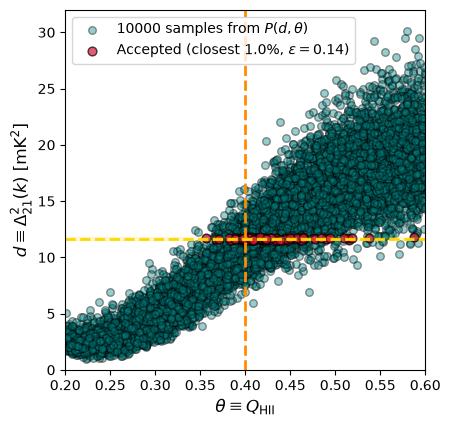

In [4]:
# Joint distribution of QHII and P21 with target observation, and ABC tolerance band
fig = plt.figure(figsize=(6, 6))

# Define axes positions
left = 0.12
bottom = 0.12
width = 0.60
height = 0.60

ax_joint = fig.add_axes([left, bottom, width, height])
# --- Joint scatter plot ---
ax_joint.scatter(qhii_prior, P_k_prior, alpha=0.4, color='teal', edgecolor='k', s=30, label=f'{num_use_samples} samples from $P(d, \\theta)$')
ax_joint.scatter(qhii_prior[accepted_indices], P_k_prior[accepted_indices],
                 alpha=0.7, color='crimson', edgecolor='k', s=40, label=f'Accepted (closest {tolerance_percentile}%, $\\epsilon = {epsilon:.2f}$)')

# Target observation
ax_joint.axhline(float(target_P_k), color='gold', linestyle='--', linewidth=2)
ax_joint.axvline(float(target_QHII), color='darkorange', linestyle='--', linewidth=2)

# Tolerance band around the target P21
ax_joint.fill_between([float(cfg["QHII_min"]), float(cfg["QHII_max"])],
                       float(target_P_k) - epsilon, float(target_P_k) + epsilon,
                       color='gold', alpha=0.15)

ax_joint.set_xlabel(r"$\theta \equiv Q_{{\mathrm{{HII}}}}$", fontsize=12)
ax_joint.set_ylabel(r"$d \equiv \Delta^2_{{21}}(k)\ [\mathrm{{mK}}^2]$", fontsize=12)
ax_joint.set_xlim(float(cfg["QHII_min"]), float(cfg["QHII_max"]))
ax_joint.set_ylim(P_k_min, P_k_max)
ax_joint.legend(fontsize=10, loc='upper left')

plt.show()

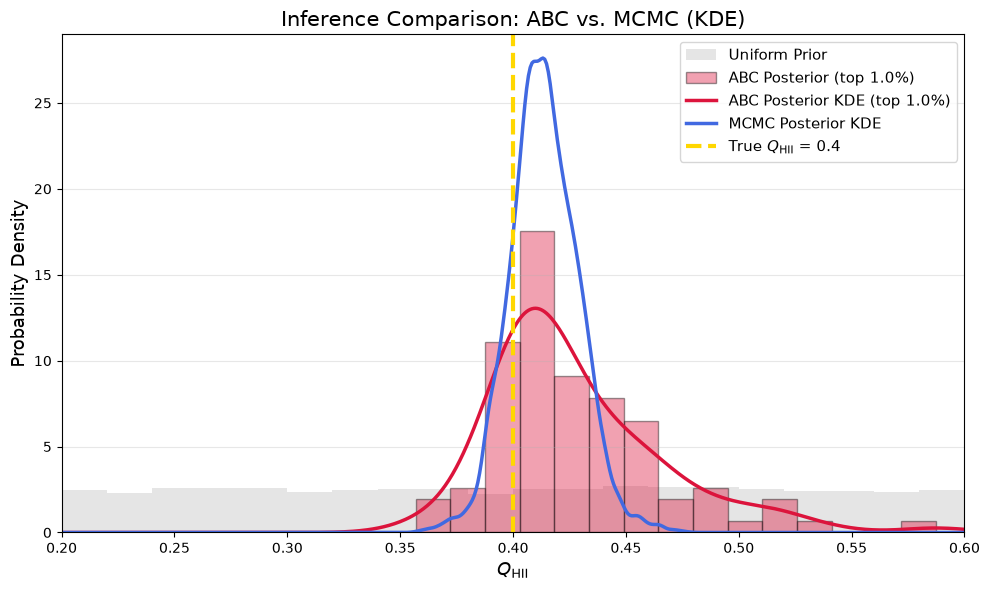

--- Inference Summary ---
True Target QHII: 0.4
ABC Median:  0.418 ± 0.038
MCMC Median: 0.413 ± 0.015


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import sim_utils

# Load Configurations
cfg = sim_utils.load_config("config.yaml")
abc_file = cfg.get("output_file", "sbi_abc_samples.npz")
mcmc_file = cfg.get("mcmc_output_file", "mcmc_samples.npz")

# Load MCMC Data
mcmc_data = np.load(mcmc_file)
mcmc_chain = mcmc_data['chain']
target_QHII = mcmc_data['target_QHII']
target_P_k = mcmc_data['target_P_k'][0]
qhii_min = mcmc_data['qhii_min']
qhii_max = mcmc_data['qhii_max']

# Process MCMC Chain (Discard burn-in and flatten)
discard_steps = int(0.5 * mcmc_chain.shape[0])  # Discard the first 50% of steps as burn-in
flat_mcmc_samples = mcmc_chain[discard_steps:, :, 0].flatten()

# --- Plotting the Comparison with KDE curves ---
plt.figure(figsize=(10, 6))

# Uniform Prior Background (light histogram)
plt.hist(qhii_prior, bins=20, density=True, alpha=0.2, color='gray', label='Uniform Prior')

# Plot the ABC Posterior
plt.hist(abc_posterior_qhii, bins=15, density=True, alpha=0.4, color='crimson', edgecolor='black', label=f'ABC Posterior (top {tolerance_percentile}%)')

# KDE grids
x_grid = np.linspace(float(qhii_min), float(qhii_max), 500)

# ABC Posterior KDE
if len(abc_posterior_qhii) > 1:
    kde_abc = gaussian_kde(abc_posterior_qhii)
    plt.plot(x_grid, kde_abc(x_grid), color='crimson', linewidth=2.5, label=f'ABC Posterior KDE (top {tolerance_percentile}%)')

# MCMC Posterior KDE
if len(flat_mcmc_samples) > 1:
    kde_mcmc = gaussian_kde(flat_mcmc_samples)
    plt.plot(x_grid, kde_mcmc(x_grid), color='royalblue', linewidth=2.5, label='MCMC Posterior KDE')

# True Target Value
plt.axvline(float(target_QHII), color='gold', linestyle='dashed', linewidth=3, 
            label=f'True $Q_{{\\mathrm{{HII}}}}$ = {target_QHII}')

plt.xlabel(r"$Q_{{\mathrm{{HII}}}}$", fontsize=13)
plt.ylabel("Probability Density", fontsize=13)
plt.title("Inference Comparison: ABC vs. MCMC (KDE)", fontsize=15)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.xlim(float(qhii_min), float(qhii_max))
plt.tight_layout()
plt.show()

# Print statistical summary
print("--- Inference Summary ---")
print(f"True Target QHII: {target_QHII}")
print(f"ABC Median:  {np.median(abc_posterior_qhii):.3f} ± {np.std(abc_posterior_qhii):.3f}")
print(f"MCMC Median: {np.median(flat_mcmc_samples):.3f} ± {np.std(flat_mcmc_samples):.3f}")

**Training the Neural Posterior Estimator (NPE)**

To overcome the inefficiencies of ABC, we turn to Simulation-Based Inference (SBI). Here, we train a Neural Spline Flow (NSF) to learn the complex, potentially non-Gaussian mapping from the observable data back to the cosmological parameters. The normalizing flow acts as our density estimator, transforming a simple base distribution into the target posterior $P(\theta|d)$ by minimizing the negative log-likelihood over our simulated pairs.

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sbi.inference import NPE_C
from sbi.utils import BoxUniform

# Define the prior bounds (reading from config)
qhii_min = cfg.get("QHII_min", 0.0)
qhii_max = cfg.get("QHII_max", 1.0)

# Convert to PyTorch Tensors
# Add an extra dimension to make them shape [N, 1]
theta = torch.tensor(qhii_prior, dtype=torch.float32).unsqueeze(1)
x = torch.tensor(P_k_prior, dtype=torch.float32).unsqueeze(1)

print(f"Theta shape: {theta.shape}")
print(f"x (Summary) shape: {x.shape}")

# Define the PyTorch Prior
prior = BoxUniform(low=torch.tensor([qhii_min]), high=torch.tensor([qhii_max]))

Theta shape: torch.Size([10000, 1])
x (Summary) shape: torch.Size([10000, 1])


In [7]:
from sbi.neural_nets import posterior_nn

print("Initializing Neural Posterior Estimator...")

# Define the customized architecture here
custom_architecture = posterior_nn(
    model="nsf",          # Neural Spline Flow (NSF) model
    num_transforms=5,     # Set your flow layers here
    hidden_features=50,   # Set your network width here
    num_bins=10           # Set your spline resolution here
)

# custom_architecture = posterior_nn(
#     model="mdn",          # Mixture Density Network (MDN) model
#     num_components=10,     # Number of Gaussians to blend together (default is usually 3)
#     hidden_features=50    # Width of the hidden layers in the network
# )

# MAF provides only a Gaussian for a single output dimension, so may not work for this simple example.

# Pass the custom architecture function to the inference engine
inference = NPE_C(
    prior=prior,
    density_estimator=custom_architecture  # Pass the builder function here
)


# Append the pre-run simulations to the inference object
inference = inference.append_simulations(theta, x)

# Train the density estimator
print("Training the neural network (this may take a moment)...")
density_estimator = inference.train()

# Build the final posterior object
sbi_posterior = inference.build_posterior(density_estimator)

print("\nTraining complete! The posterior is ready for inference.")
sbi_posterior_outfile = f'sbi_posterior_samp_{num_use_samples}.pt'
torch.save(sbi_posterior, sbi_posterior_outfile)
print(f"Saved the trained posterior to {sbi_posterior_outfile}.")

Initializing Neural Posterior Estimator...
Training the neural network (this may take a moment)...
 Neural network successfully converged after 69 epochs.
Training complete! The posterior is ready for inference.
Saved the trained posterior to sbi_posterior_samp_10000.pt.


**Evaluating Inference Accuracy**

With the neural network converged, we can draw samples directly from the newly modeled posterior. We will compare this NPE posterior against our Rejection ABC results and the true target $Q_{\mathrm{HII}}$ value. A well-calibrated NPE should produce a more accurate posterior, extracting more information from the same number of simulations than ABC.

  0%|          | 0/10000 [00:00<?, ?it/s]

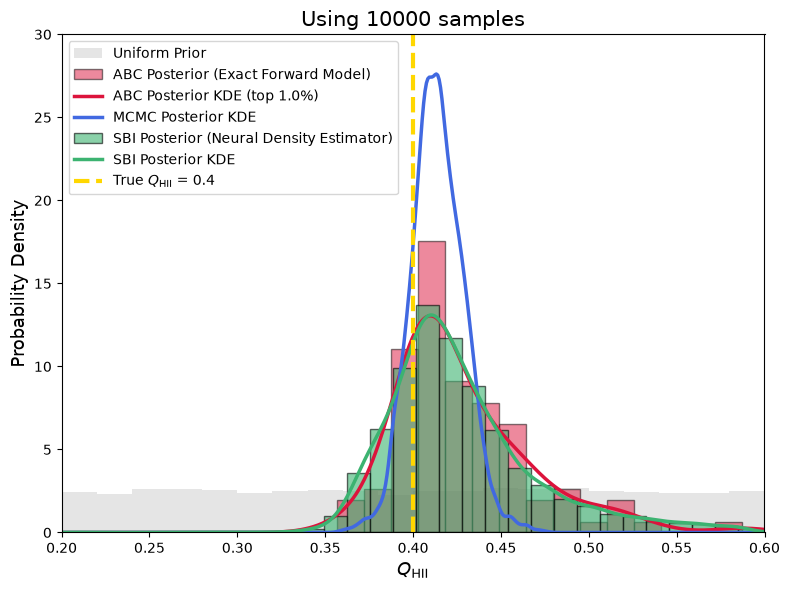

--- SBI Inference Summary ---
True Target QHII: 0.4
SBI Mean: 0.427 ± 0.043


In [ ]:
# Set flags for plotting

plot_MCMC = True
plot_ABC = True
plot_SBI = True

# Define the target observation as a PyTorch tensor
target_QHII = cfg["target_QHII"]

# Cast to float to avoid NumPy 0D-array compatibility issues with PyTorch
x_obs = torch.tensor([[float(target_P_k)]], dtype=torch.float32)

# Draw 10,000 samples from the SBI posterior instantly
sbi_samples = sbi_posterior.sample((10000,), x=x_obs)
sbi_samples_np = sbi_samples.numpy().flatten()

# --- Plotting: SBI vs ABC vs MCMC ---
plt.figure(figsize=(8, 6))

# Uniform Prior Background
plt.hist(qhii_prior, bins=20, density=True, alpha=0.2, color='gray', label='Uniform Prior')

if plot_ABC:
    # ABC Posterior (assuming abc_posterior_qhii exists from the previous cell)
    if 'abc_posterior_qhii' in locals():
        plt.hist(abc_posterior_qhii, bins=15, density=True, alpha=0.5, color='crimson', 
                edgecolor='black', label='ABC Posterior (Exact Forward Model)')
        
        # ABC Posterior KDE
        if len(abc_posterior_qhii) > 1:
            plt.plot(x_grid, kde_abc(x_grid), color='crimson', linewidth=2.5, label=f'ABC Posterior KDE (top {tolerance_percentile}%)')

if plot_MCMC:
    # MCMC Posterior KDE
    if len(flat_mcmc_samples) > 1:
        plt.plot(x_grid, kde_mcmc(x_grid), color='royalblue', linewidth=2.5, label='MCMC Posterior KDE')

if plot_SBI:
# SBI Posterior
    plt.hist(sbi_samples_np, bins=30, density=True, alpha=0.6, color='mediumseagreen', 
            edgecolor='black', label='SBI Posterior (Neural Density Estimator)')
    if len(sbi_samples_np) > 1:
        kde_sbi = gaussian_kde(sbi_samples_np)
        plt.plot(x_grid, kde_sbi(x_grid), color='mediumseagreen', linewidth=2.5, label='SBI Posterior KDE')

# True Target Value
plt.axvline(target_QHII, color='gold', linestyle='dashed', linewidth=3, 
            label=f'True $Q_{{\\mathrm{{HII}}}}$ = {target_QHII}')

plt.xlabel(r"$Q_{{\mathrm{{HII}}}}$", fontsize=13)
plt.ylabel("Probability Density", fontsize=13)
plt.title(f"Using {num_use_samples} samples", fontsize=15)
plt.legend(fontsize=10)
plt.xlim(qhii_min, qhii_max)
plt.ylim(0,30)
plt.tight_layout()
plt.show()

**Synthesis & Forward Outlook**

In this notebook, we have demonstrated that Neural Posterior Estimation (NPE) provides a highly efficient, likelihood-free alternative to traditional Approximate Bayesian Computation. By training a Neural Spline Flow on our forward-modelled mock dataset, we successfully recovered the underlying ionization fraction ($Q_{\mathrm{HII}}$) without the massive sample-rejection waste characteristic of ABC. 

More importantly, NPE *amortizes* the cost of inference. Once the network is trained on the simulation bank, evaluating the posterior for any new observation is practically instantaneous—a critical advantage when dealing with expensive astrophysics simulations.

As we scale up our pipeline, calculating simple Euclidean distances on a single power spectrum bin will no longer suffice. Moving forward, we will apply these SBI frameworks directly to the outputs of the SCRIPT semi-numerical code. Our objective will be to infer a multi-dimensional parameter space, such as ionizing efficiencies and minimum halo masses, from comprehensive 21-cm tomographic lightcones.

**Next Step Challenge:** 

Consider the vast dimensionality of a full 21-cm map. Feeding raw simulation cubes directly into a normalizing flow is computationally intractable. How might we optimally compress these SCRIPT outputs into a handful of robust summary statistics before performing inference?